# 01 · Cohort overview

What was run, on which scenes, and the headline numbers. Nothing here is a verdict – the purpose of
these notebooks is to lay out the evidence so **you** decide whether the lesion outlines are right.

**Colour key used throughout**: <span style="color:#eda100">■</span> automatic lesion outline ·
<span style="color:#e34948">■</span> automatic core · <span style="color:#e87ba4">■</span> manual CORE (collaborator, dashed) ·
zones <span style="color:#3987e5">■ distal (control)</span> <span style="color:#9085e9">■ deep</span> <span style="color:#199e70">■ peri</span> <span style="color:#c98500">■ rim</span> <span style="color:#e66767">■ core</span>.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


## Settings of this run

In [2]:
L = runs[0].log
settings = {
    "lesion score": L["lesion"]["score"],
    "model": L.get("lesion_model", {}).get("path", "–"),
    "threshold": L["lesion"]["threshold"],
    "rim width": L["lesion"]["rim_width_um"], "peri width": L["lesion"]["peri_width_um"],
    "relative widths (fraction of section radius)": L.get("zone_widths_relative"),
    "section focus": L["section_focus"]["mode"],
    "Pu.1 calls": L["pu1"]["method"],
    "density grid / smoothing (µm)": (L["config"]["density"]["bin_um"], L["config"]["density"]["sigma_um"]),
}
pd.DataFrame({"setting": list(settings), "value": [str(v) for v in settings.values()]})

,setting,value
0,lesion score,model
1,model,/Users/chrislangseth/work/karolinska_institute...
2,threshold,"{'type': 'absolute', 'value': 0.25, 'seed': 0.5}"
3,rim width,"{'per_bin_um': True, 'median_um': 49.257659912..."
4,peri width,"{'per_bin_um': True, 'median_um': 147.77297973..."
5,relative widths (fraction of section radius),"{'rim': 0.05, 'peri': 0.15, 'deep': 0.15}"
6,section focus,manual
7,Pu.1 calls,mask
8,density grid / smoothing (µm),"(10, 40)"


## Headline numbers per scene

In [3]:
R.cohort_table(runs)

,scene,cells,Pu.1+,Pu.1+ frac,lesions,lesion sections,sections,auto lesion mm²,manual core mm²,manual cores,cores ≥50% covered,manual area covered,wells
0,CML_1 scene 0,57044,17315,0.304,22,5,9,1.95,0.69,34,0.705882,0.90,40
1,CML_2_rescan scene 0,60095,13214,0.220,30,3,9,1.78,0.97,25,0.920000,0.85,30
2,CML_metal scene 0,50627,15502,0.306,19,5,9,1.30,0.44,33,0.727273,0.87,41
3,CML_metal scene 1,50980,17992,0.353,30,3,9,2.23,0.36,20,0.950000,0.97,29


## Pu.1⁺ cells straight from the segmentation mask

Counts of segmented cells and Pu.1⁺ calls (the collaborator's `Pu1_class`) per scene, per section
(animal + spinal level) and per animal. No zoning involved.

In [4]:
coh = Path(RUN_DIR) / "cohort"
display(pd.read_csv(coh / "pu1_counts_total.csv").round(3))
pc = pd.read_csv(coh / "pu1_counts_by_section.csv")
display(pc.pivot_table(index=["animal", "level", "section"], columns="sample", values="n_pu1_pos", aggfunc="sum", fill_value=0).astype(int))
display(pd.read_csv(coh / "pu1_counts_by_animal.csv").round(3))

,sample,scene,n_cells,n_pu1_pos,frac_pu1
0,CML_1,0.0,57044,17315,0.304
1,CML_2_rescan,0.0,60095,13214,0.220
2,CML_metal,0.0,50627,15502,0.306
3,CML_metal,1.0,50980,17992,0.353
4,ALL,NaN,218746,64023,0.293


sample                 CML_1  CML_2_rescan  CML_metal
animal level section                                 
CFA_L2 C     CFA_L2_C      0           468        929
       L     CFA_L2_L      0           446        843
       T     CFA_L2_T      0           214        211
OS1_2  C     OS1_2_C     502             0        883
       L     OS1_2_L     496             0        737
P2_3   C     P2_3_C     4279             0       3076
       L     P2_3_L     3150             0       2865
       T     P2_3_T     3749             0       2985
P3_1   C     P3_1_C        0          3409       4148
       L     P3_1_L        0           938        708
       T     P3_1_T        0          1680       1900
R1_2   C     R1_2_C        0           121         19
       L     R1_2_L        0          1200       1557
       T     R1_2_T        0          4735       7664
R1_3   C     R1_3_C     2076             0       1968
       L     R1_3_L     1709             0       1634
       T     R1_3_T     1065             0        993

,animal,level,n_sections,n_cells,n_pu1_pos,area_pu1_um2,frac_pu1
0,CFA_L2,C,2,9425,1397,48523.351,0.148
1,CFA_L2,L,2,9944,1289,44694.480,0.130
2,CFA_L2,T,2,4667,425,13682.922,0.091
3,OS1_2,NaN,2,5081,616,20062.261,0.121
4,OS1_2,C,2,9248,1385,43038.029,0.150
5,OS1_2,L,2,8107,1233,41263.947,0.152
6,P2_3,C,2,19295,7355,210880.707,0.381
7,P2_3,L,2,20138,6015,183980.948,0.299
8,P2_3,T,2,14622,6734,181164.358,0.461
9,P3_1,C,2,22451,7557,234566.699,0.337


## Per-scene overview figures

### CML_1 scene 0

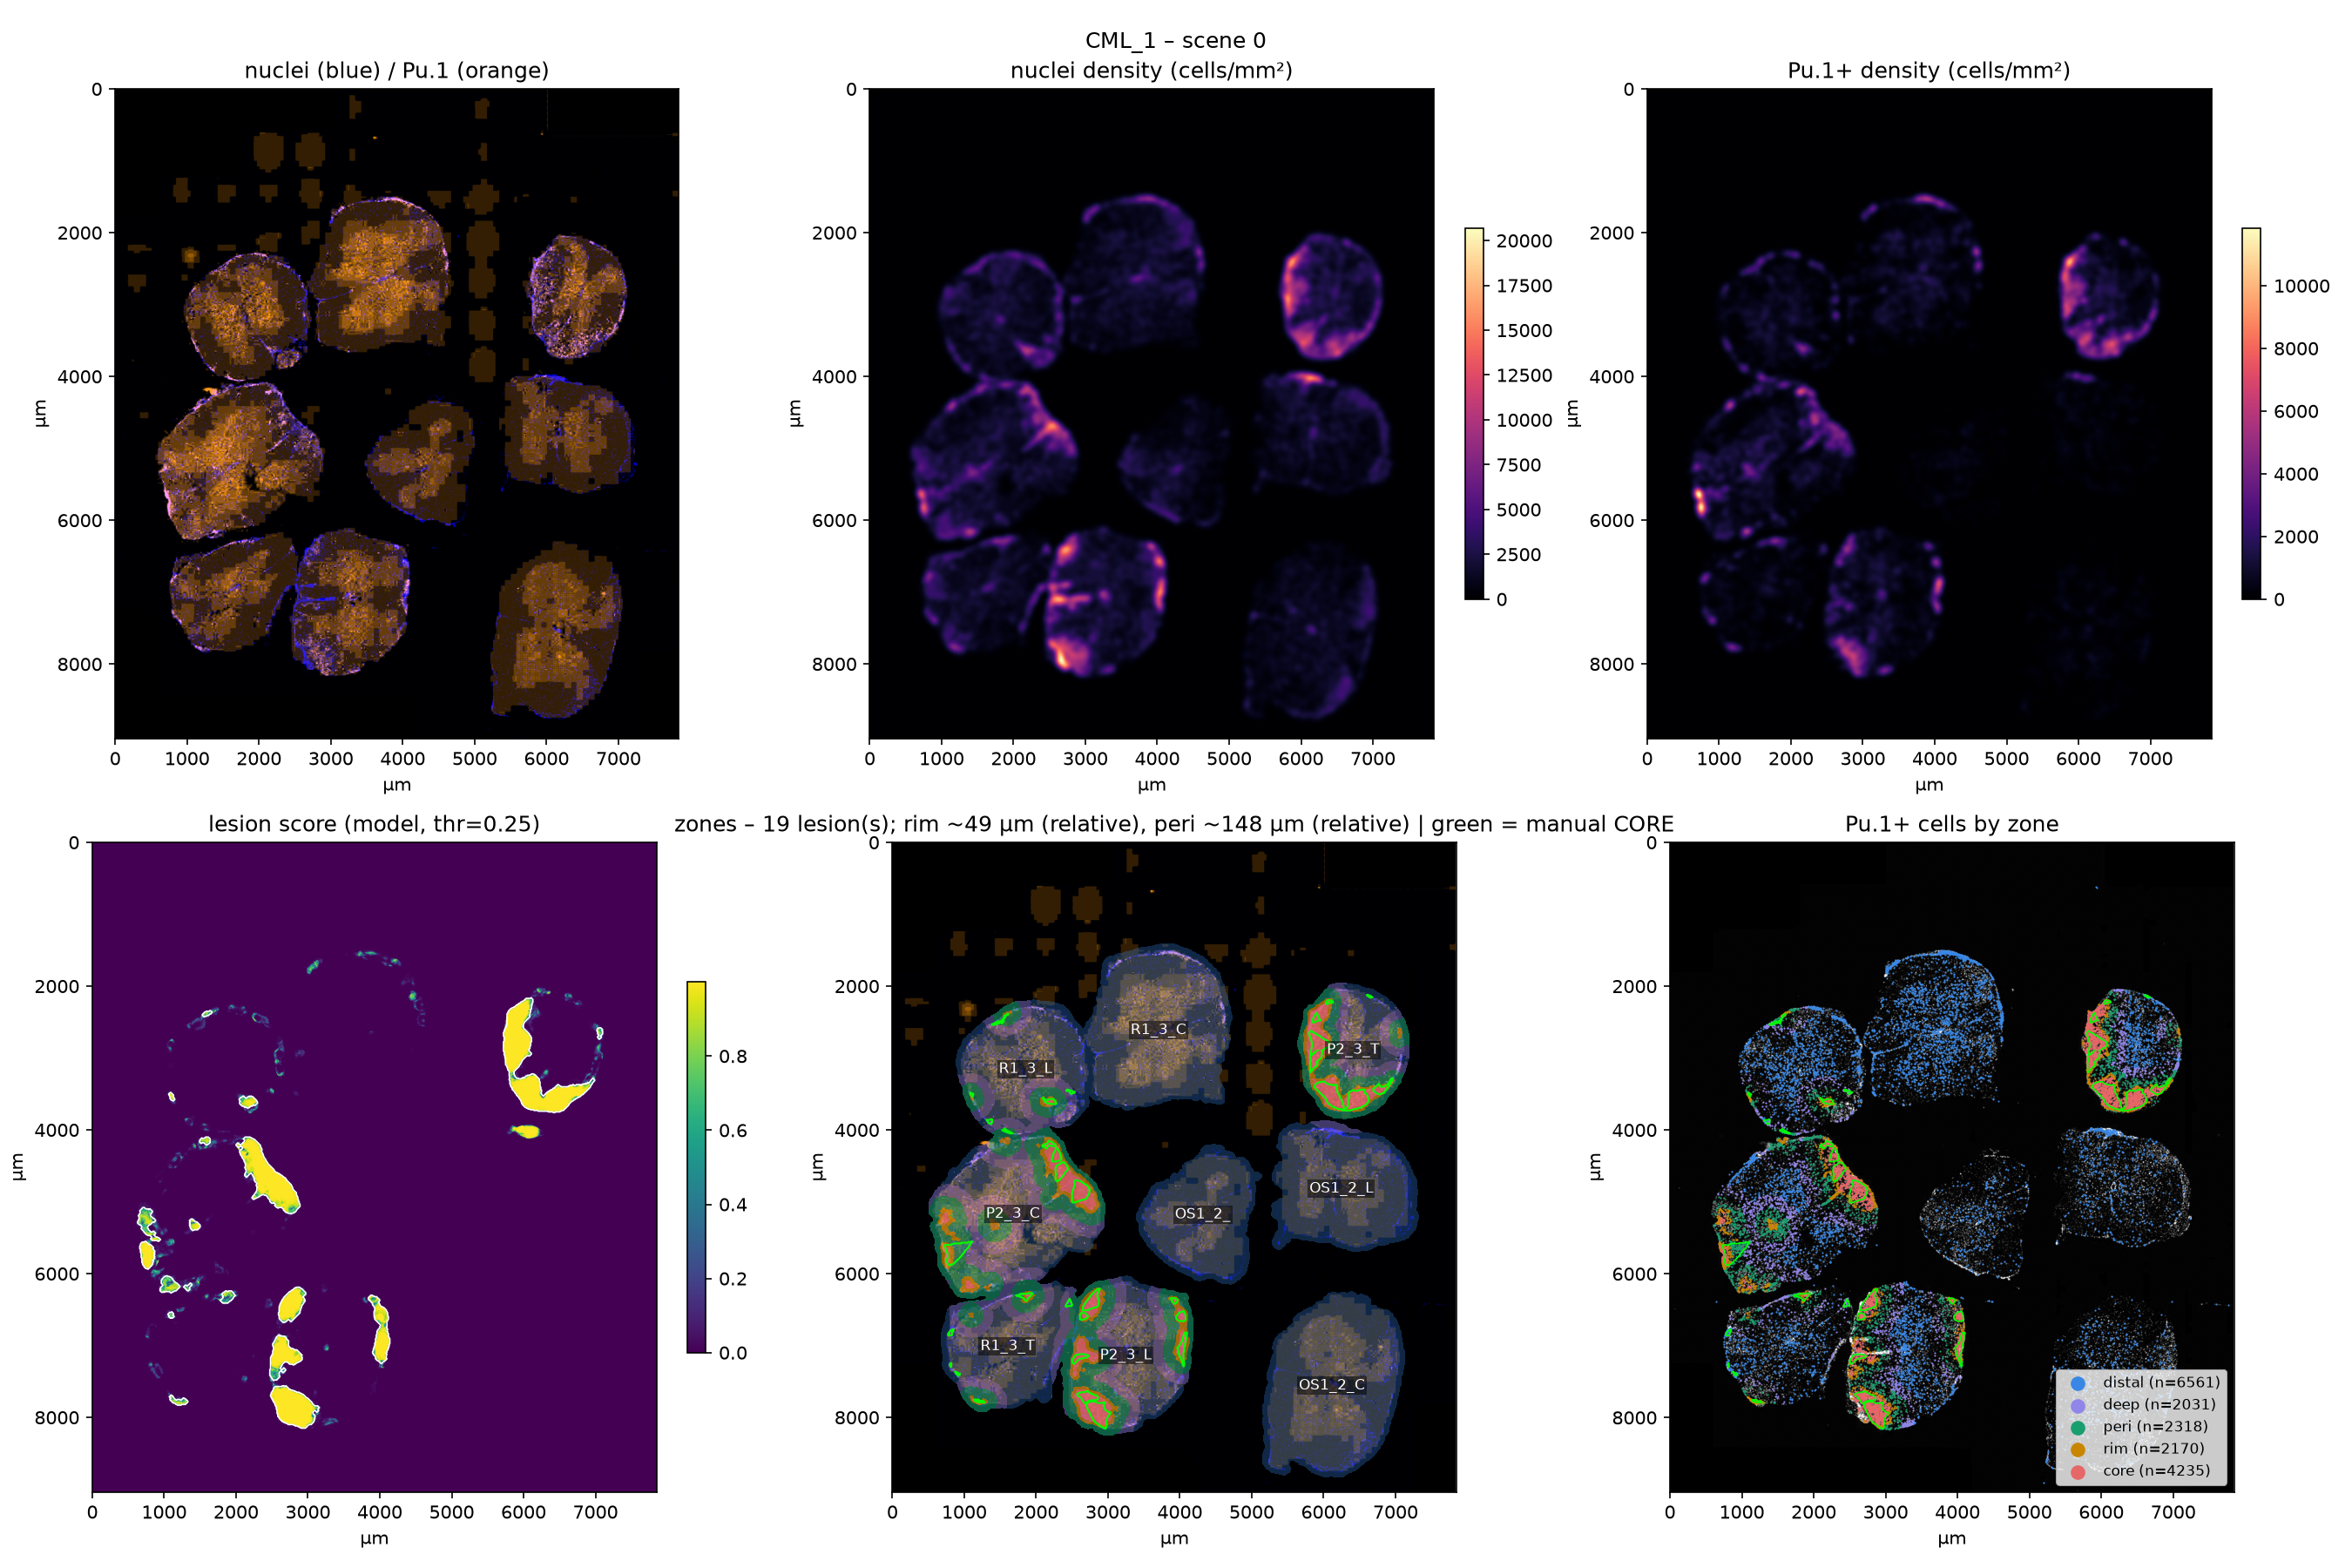

### CML_2_rescan scene 0

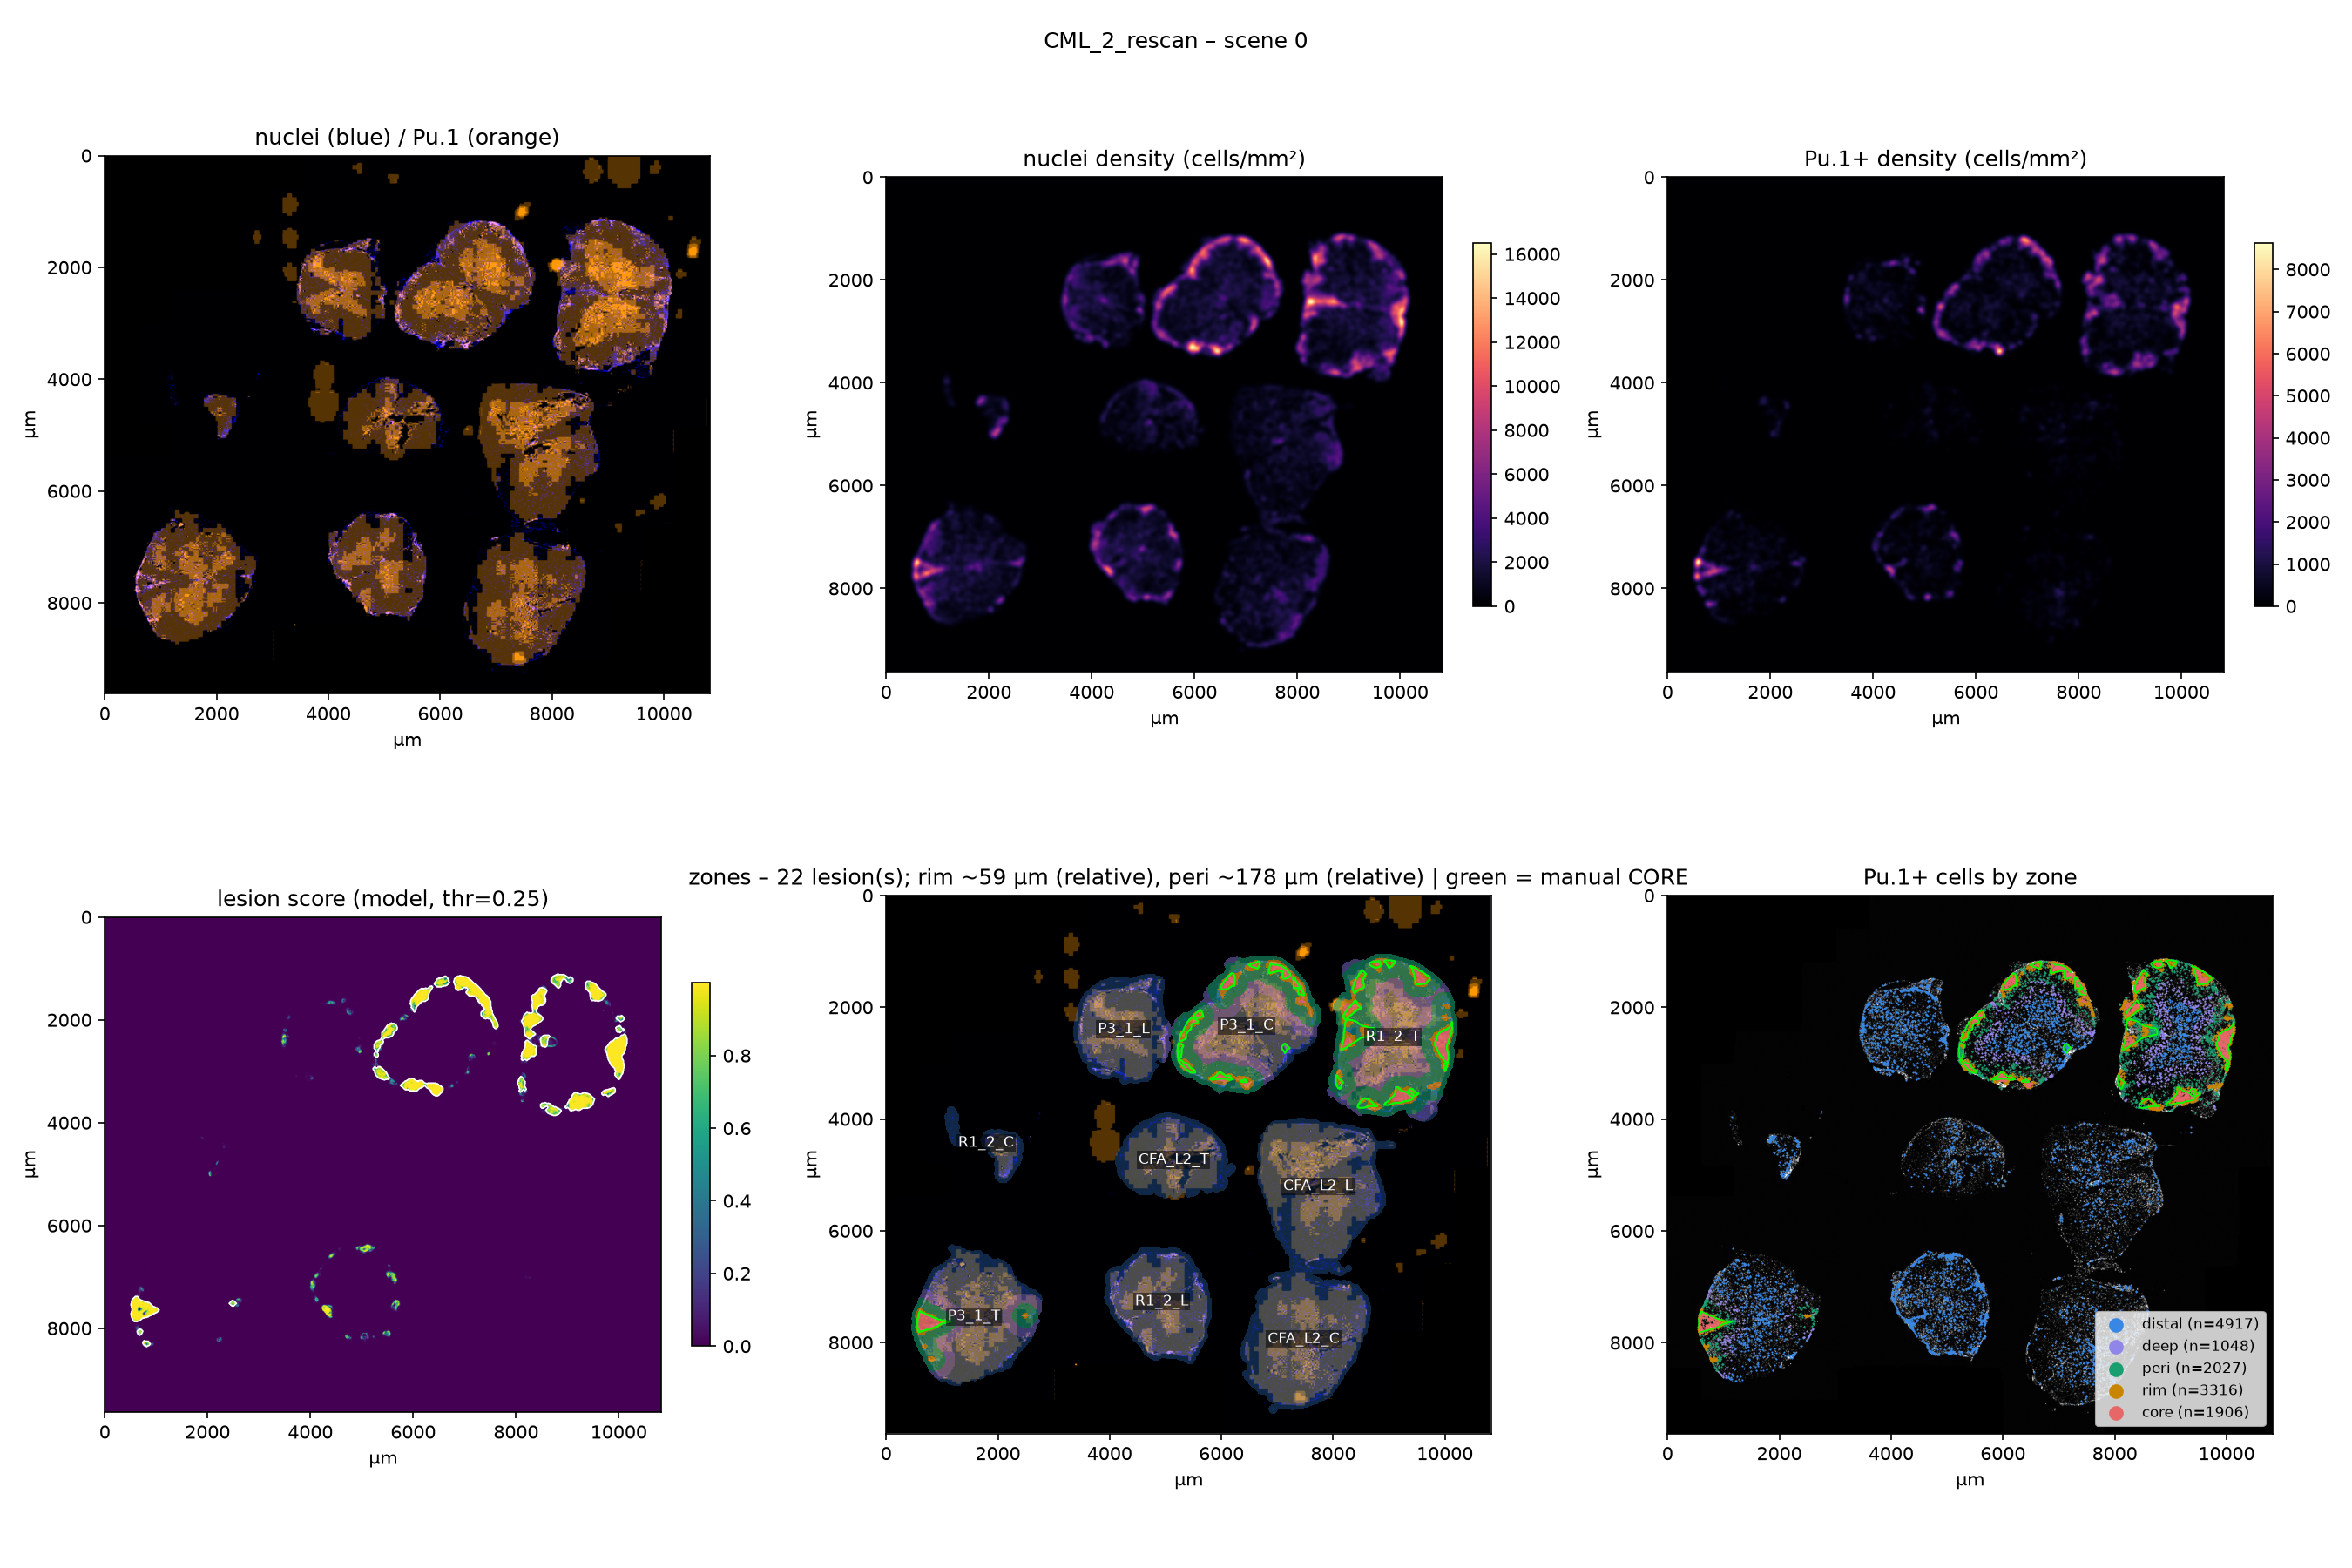

### CML_metal scene 0

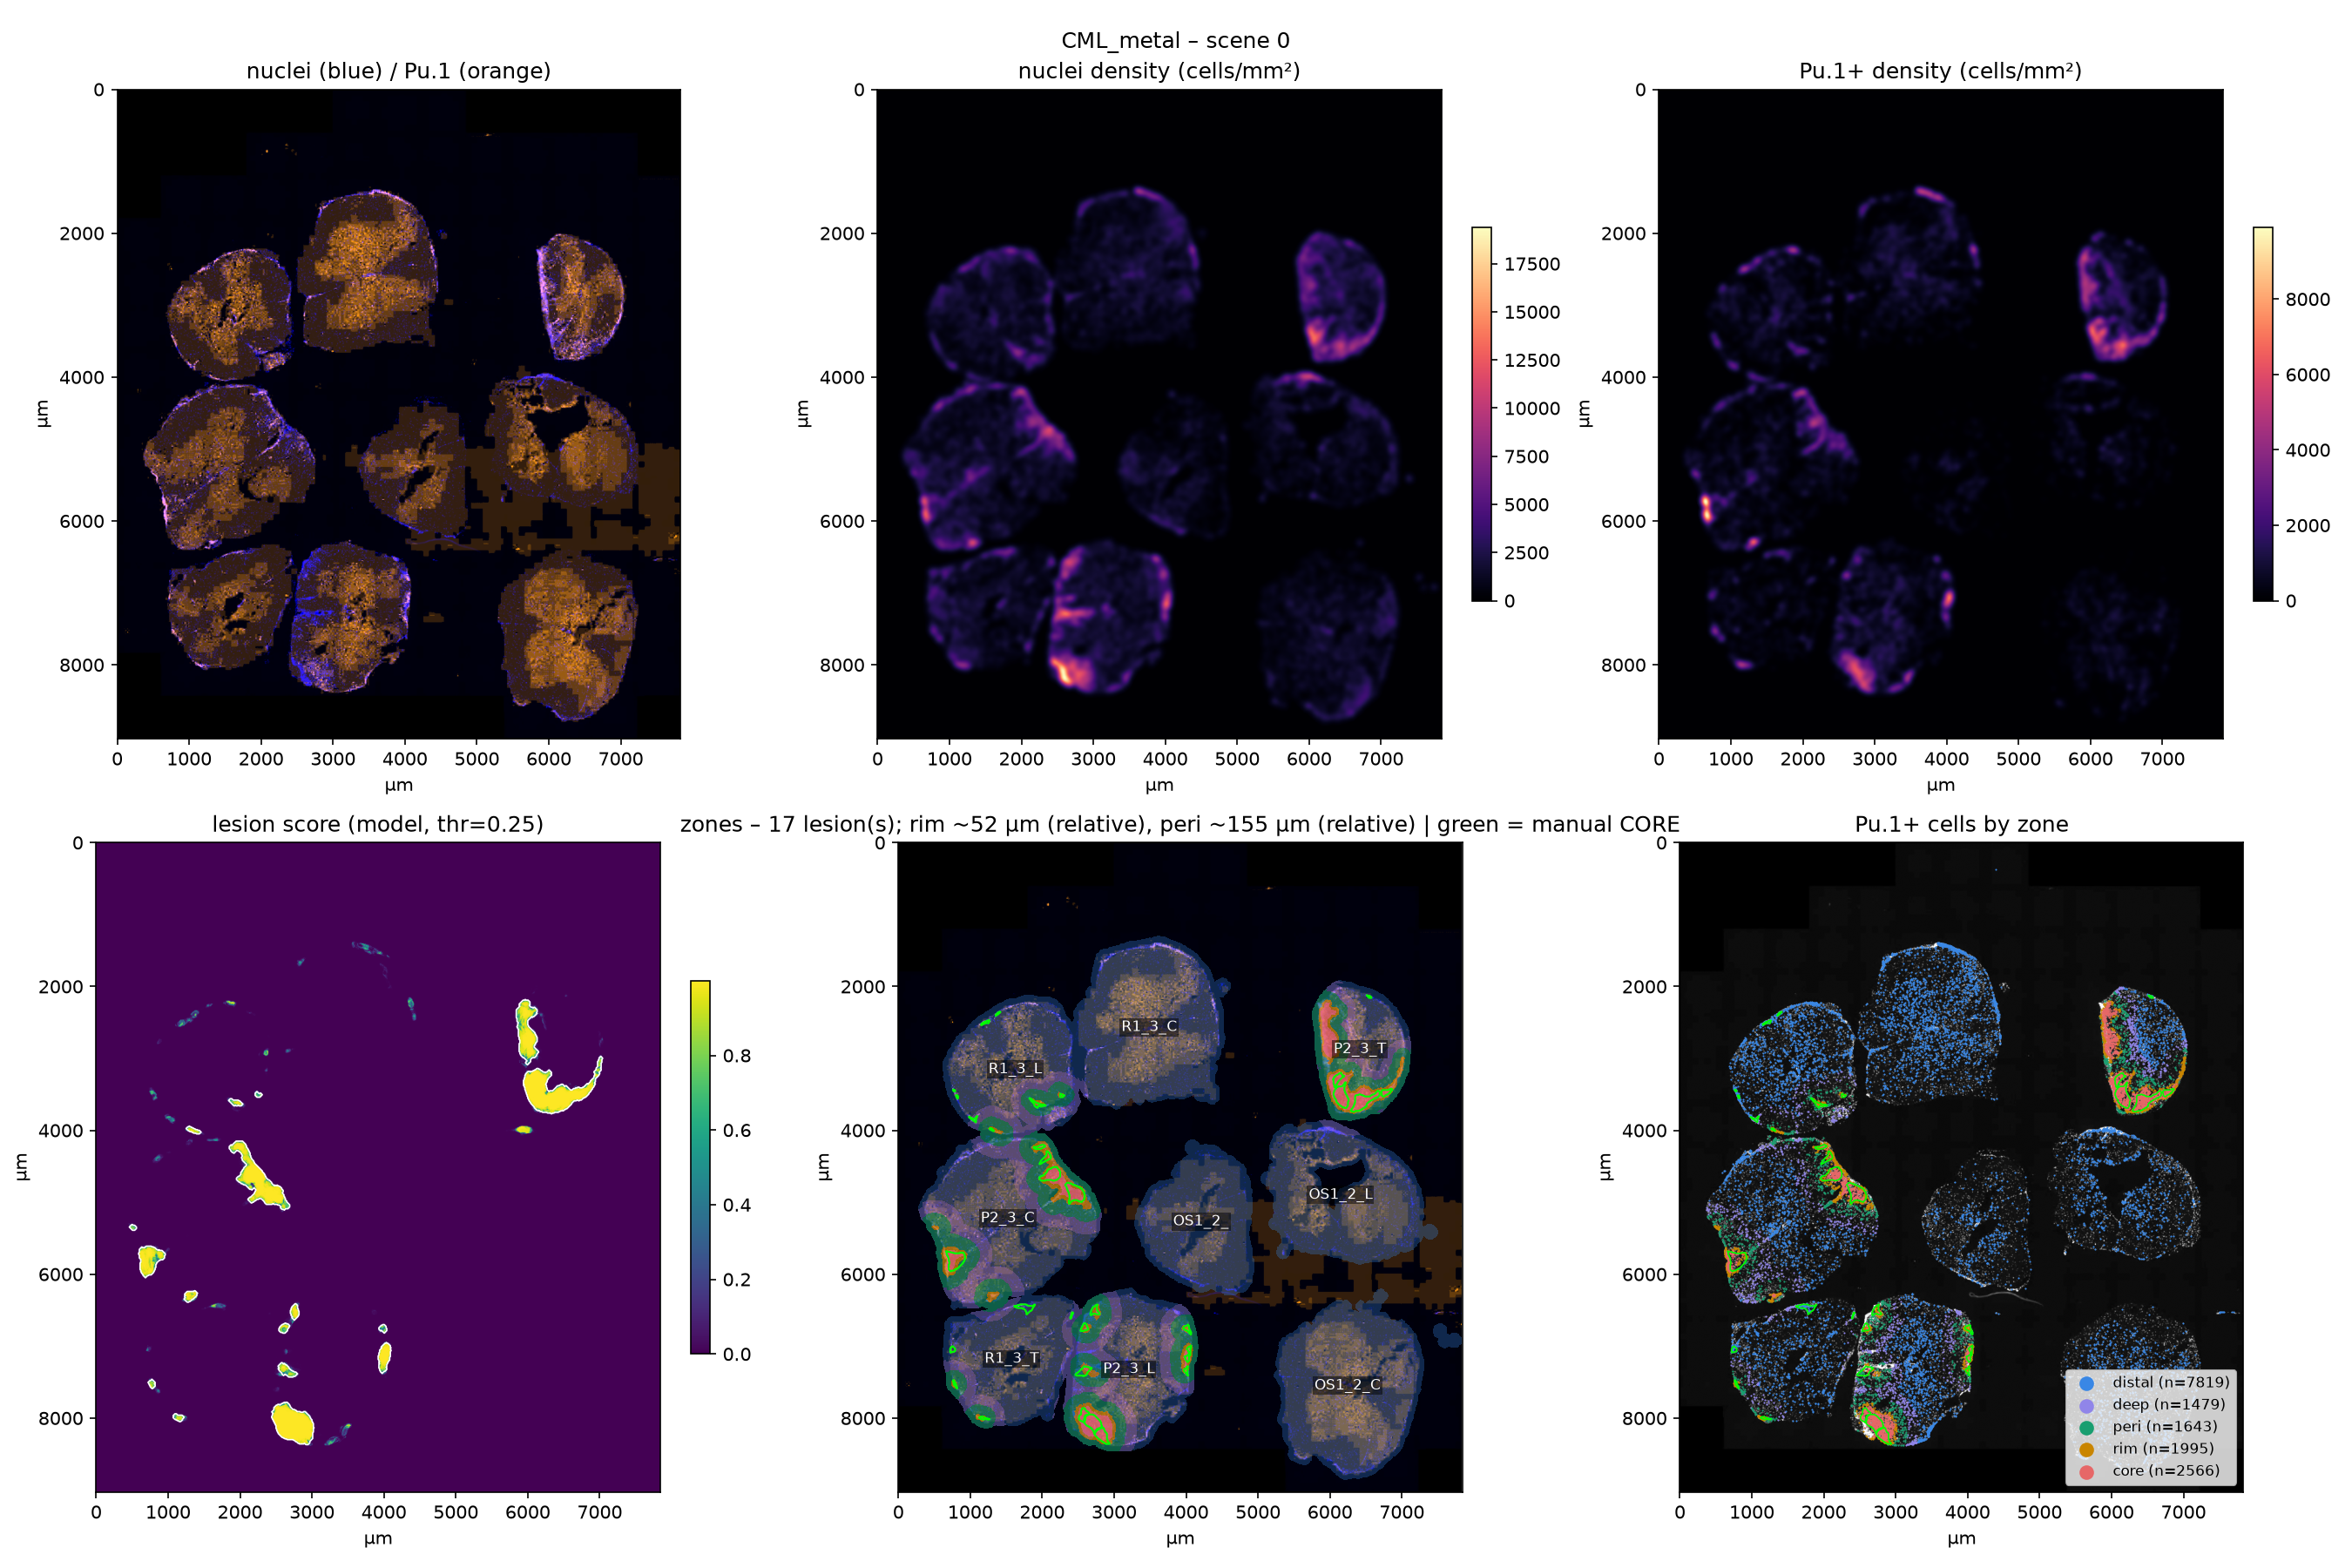

### CML_metal scene 1

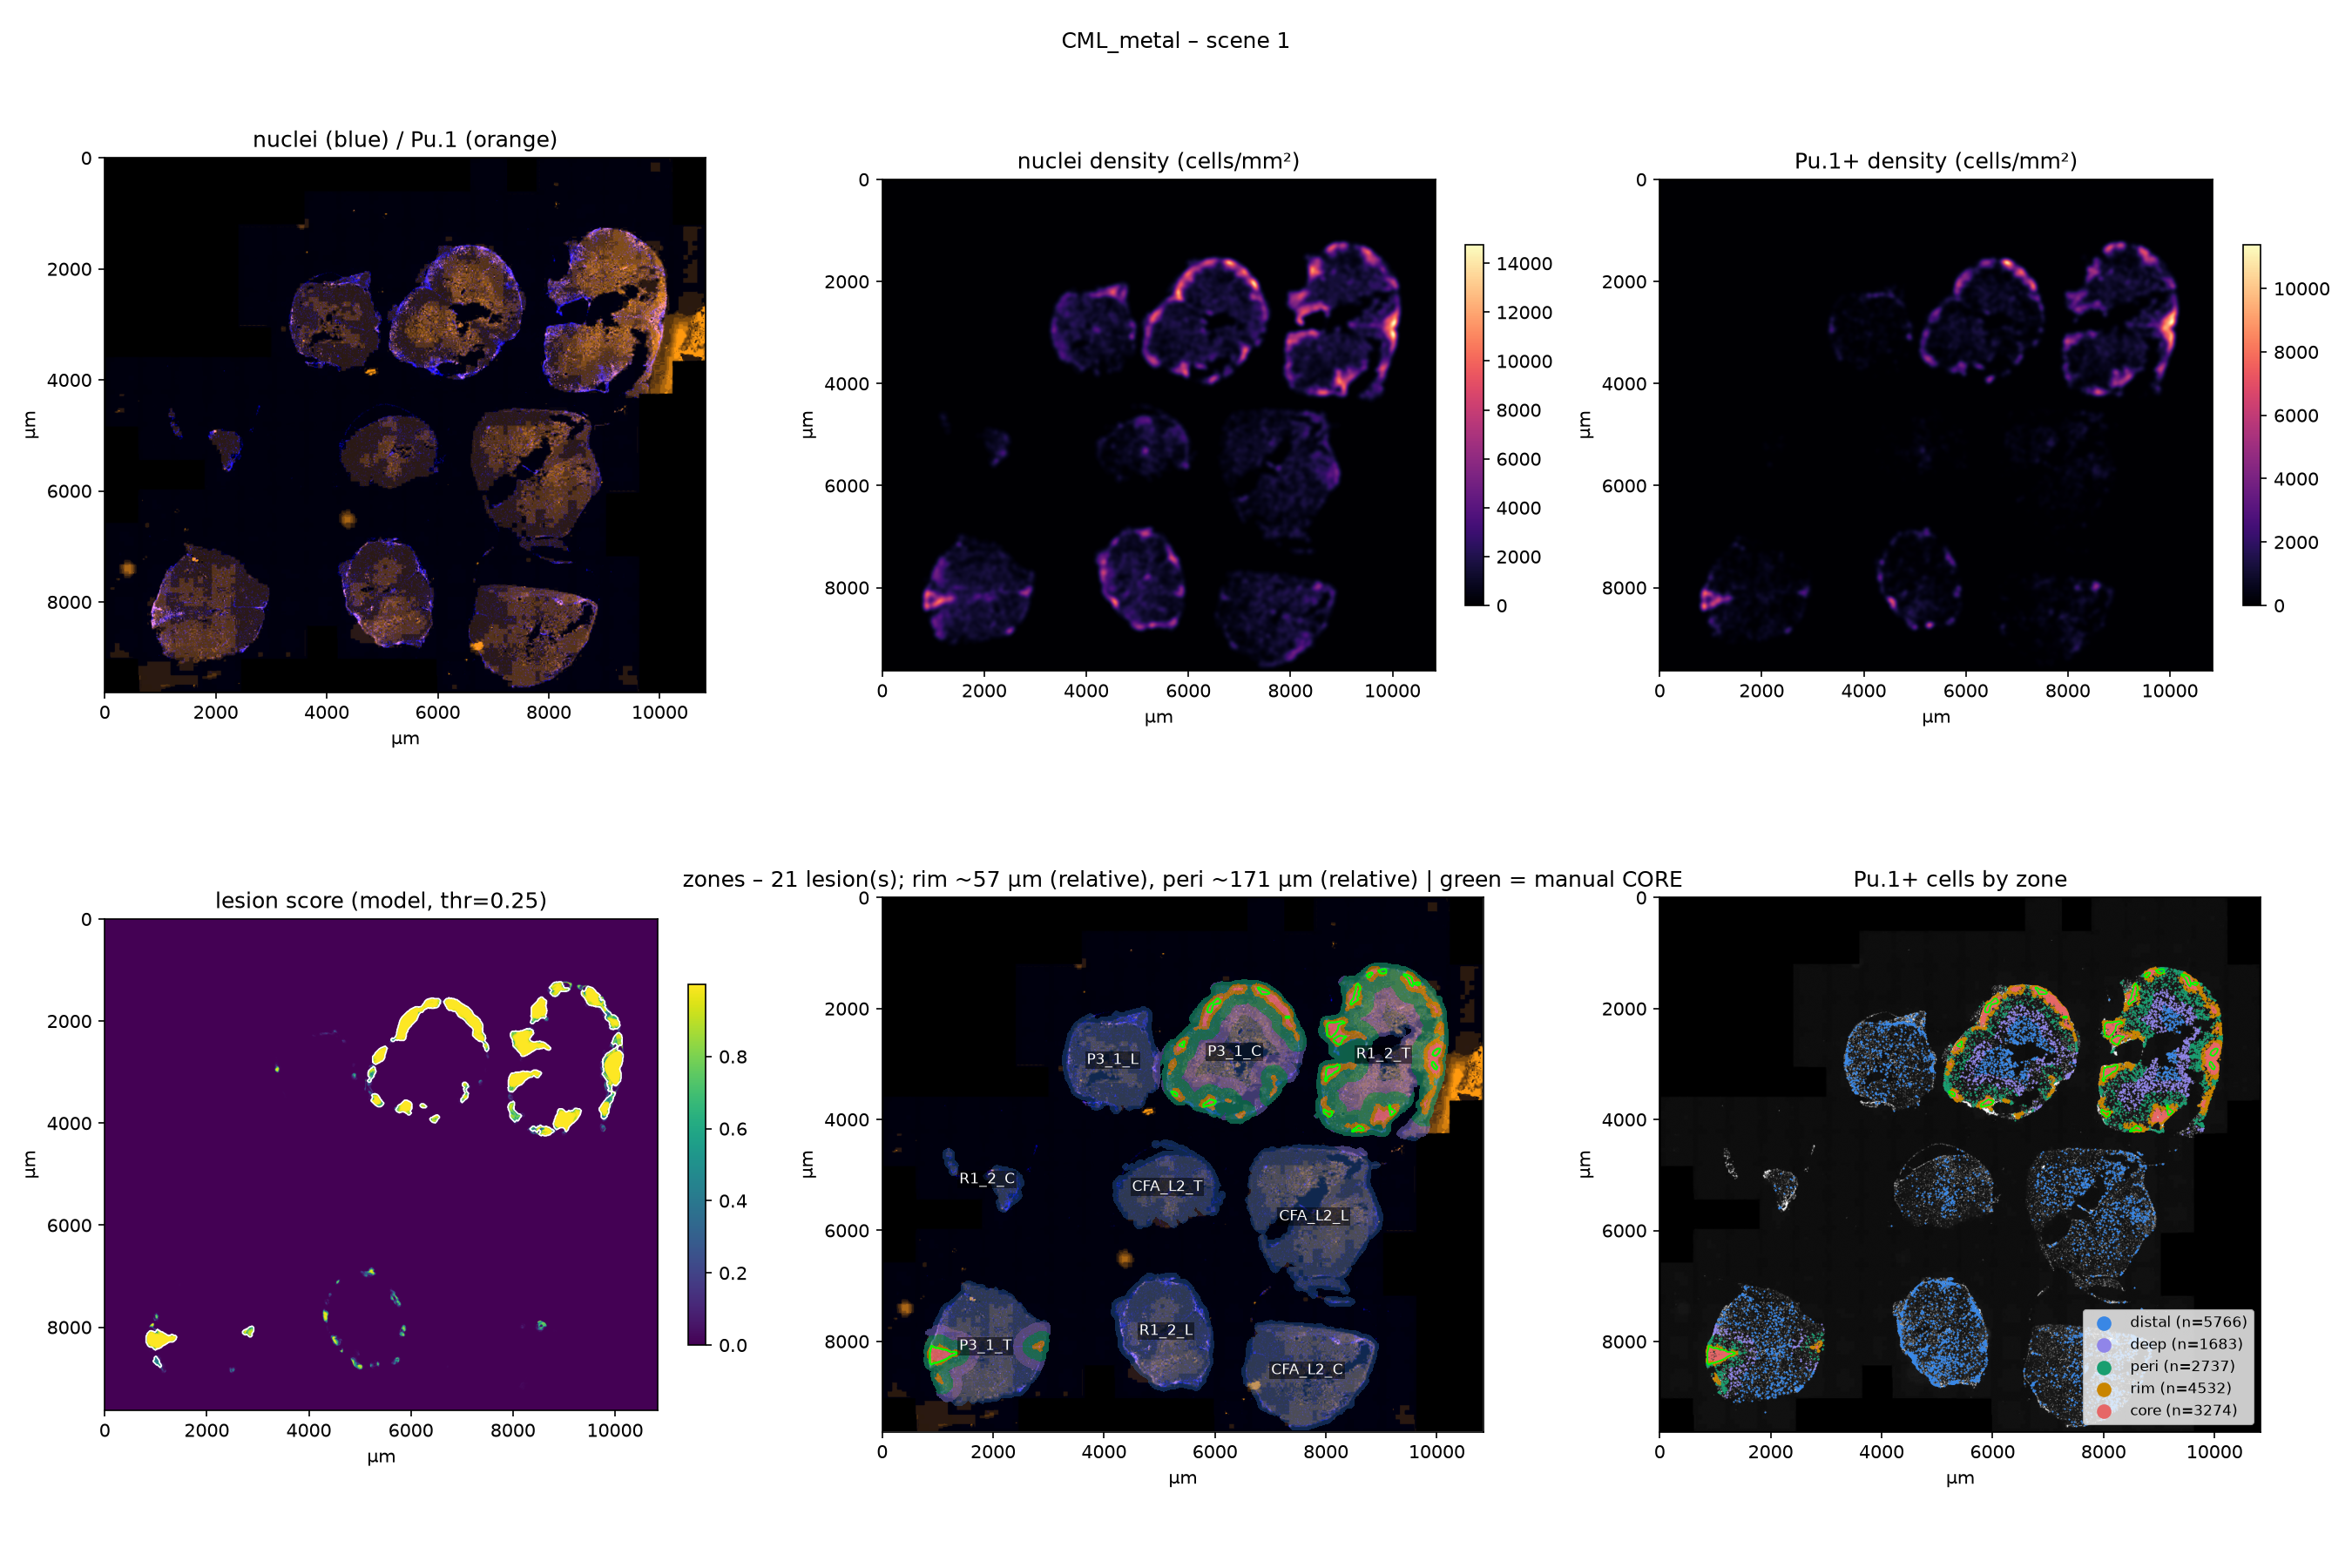

In [5]:
for r in runs:
    display(Markdown(f"### {r.name}"))
    display(Image(filename=str(r.dir / "overview.png"), width=1400))

## Sections: lesion vs control, Pu.1⁺ fraction, lesion burden

`is_lesion_section` is the data-driven / manual-guided classification used in this run; `has_manual_core`
says whether the collaborator drew a core there. `lesion_area_frac_unrestricted` is what the detector
found *before* the control sections were cleared.

In [6]:
sec = R.sections_table(runs)
cols = ["scene", "section_name", "is_lesion_section", "has_manual_core", "area_mm2", "n_cells", "n_pu1_pos", "frac_pu1_pos",
        "n_lesions", "lesion_area_mm2", "lesion_frac_of_section", "lesion_area_frac_unrestricted", "n_auto_lesions_unrestricted"]
sec[[c for c in cols if c in sec]].round(3)

,scene,section_name,is_lesion_section,has_manual_core,area_mm2,n_cells,n_pu1_pos,frac_pu1_pos,n_lesions,lesion_area_mm2,lesion_frac_of_section,lesion_area_frac_unrestricted,n_auto_lesions_unrestricted
0,CML_1 scene 0,P2_3_T,True,True,2.101,8293,3749,0.452,2,0.625,0.298,0.300,2
1,CML_1 scene 0,R1_3_C,False,False,3.861,6085,2076,0.341,0,0.000,0.000,0.005,2
2,CML_1 scene 0,R1_3_L,True,True,2.667,5523,1709,0.309,3,0.042,0.016,0.016,3
3,CML_1 scene 0,OS1_2_L,False,False,3.026,4493,496,0.110,0,0.000,0.000,0.018,1
4,CML_1 scene 0,OS1_2_,False,False,2.390,2677,272,0.102,0,0.000,0.000,0.000,0
5,CML_1 scene 0,P2_3_C,True,True,3.915,10078,4279,0.425,7,0.578,0.148,0.148,7
6,CML_1 scene 0,OS1_2_C,False,False,4.241,4772,502,0.105,0,0.000,0.000,0.000,0
7,CML_1 scene 0,P2_3_L,True,True,3.049,10589,3150,0.297,4,0.663,0.217,0.218,4
8,CML_1 scene 0,R1_3_T,True,True,2.545,4475,1065,0.238,3,0.046,0.018,0.018,3
9,CML_2_rescan scene 0,R1_2_T,True,True,5.456,15587,4735,0.304,12,0.941,0.172,0.172,12


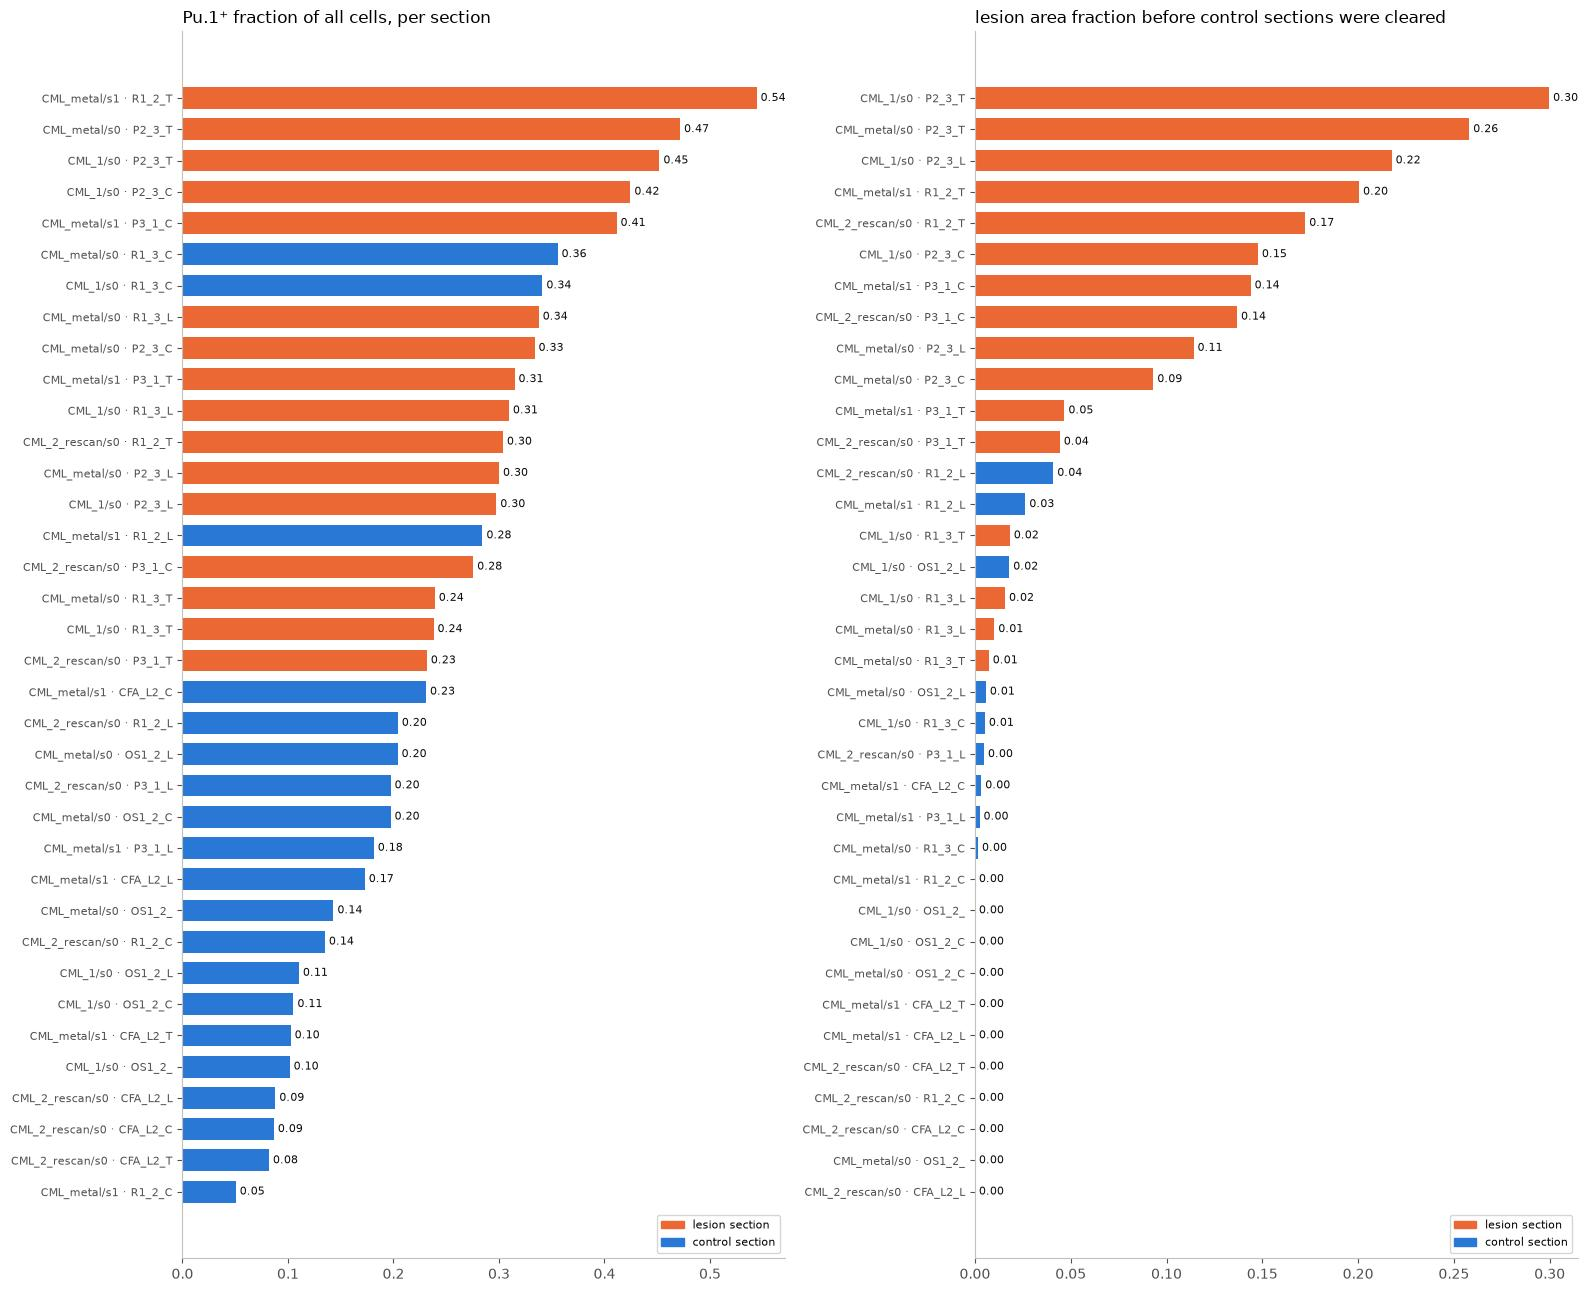

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 0.32 * len(sec) + 1.5))
R.bar_by_section(sec, "frac_pu1_pos", ax=axes[0], title="Pu.1⁺ fraction of all cells, per section")
R.bar_by_section(sec, "lesion_area_frac_unrestricted", ax=axes[1], title="lesion area fraction before control sections were cleared")
plt.tight_layout()